# 📊 Task 4 — Data Storytelling & Statistical Validation
## Superstore Sales Dataset — Real Data Analysis

**Analyst:** Vikas Navik  
**GitHub:** github.com/vikasnishad54vertfgcea  
**LinkedIn:** linkedin.com/in/vikas-navik-a00029313  
**Internship Project | Task 4 | 16-Day Timeline**

---

### 📖 Dataset Info
| Property | Value |
|----------|-------|
| Dataset | Superstore Sales |
| Total Orders | 9,994 |
| Columns | 21 |
| Time Period | 2015–2018 |
| Categories | Furniture, Office Supplies, Technology |
| Regions | East, West, Central, South |

---

### 🎯 Business Hypothesis
| | Hypothesis |
|---|---|
| **H₀ (Null)** | Discounts do **NOT** significantly reduce profit per order |
| **H₁ (Alternate)** | Discounts **significantly reduce** profit — high discounts hurt the business |

---

## 📦 Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 📂 Step 2 — Load & Explore Dataset

In [3]:
df = pd.read_csv('dataset.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Has Discount'] = df['Discount'].apply(lambda x: 'Discounted' if x > 0 else 'No Discount')

print('=' * 55)
print('📊  SUPERSTORE DATASET — OVERVIEW')
print('=' * 55)
print(f'  Total Orders     : {len(df):,}')
print(f'  Total Revenue    : ${df["Sales"].sum():,.2f}')
print(f'  Total Profit     : ${df["Profit"].sum():,.2f}')
print(f'  Profit Margin    : {(df["Profit"].sum()/df["Sales"].sum()*100):.2f}%')
print(f'  Avg Order Value  : ${df["Sales"].mean():,.2f}')
print(f'  Date Range       : {df["Order Date"].min().date()} to {df["Order Date"].max().date()}')
print(f'  Categories       : {", ".join(df["Category"].unique())}')
print(f'  Regions          : {", ".join(df["Region"].unique())}')
print(f'  Segments         : {", ".join(df["Segment"].unique())}')
print('=' * 55)

df.head()

📊  SUPERSTORE DATASET — OVERVIEW
  Total Orders     : 9,994
  Total Revenue    : $2,297,200.86
  Total Profit     : $286,397.02
  Profit Margin    : 12.47%
  Avg Order Value  : $229.86
  Date Range       : 2014-01-03 to 2017-12-30
  Categories       : Furniture, Office Supplies, Technology
  Regions          : South, West, Central, East
  Segments         : Consumer, Corporate, Home Office


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Has Discount
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Discounted
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Discounted


---
## 📈 Step 3 — Sales Trend Analysis (Part 1 Findings)

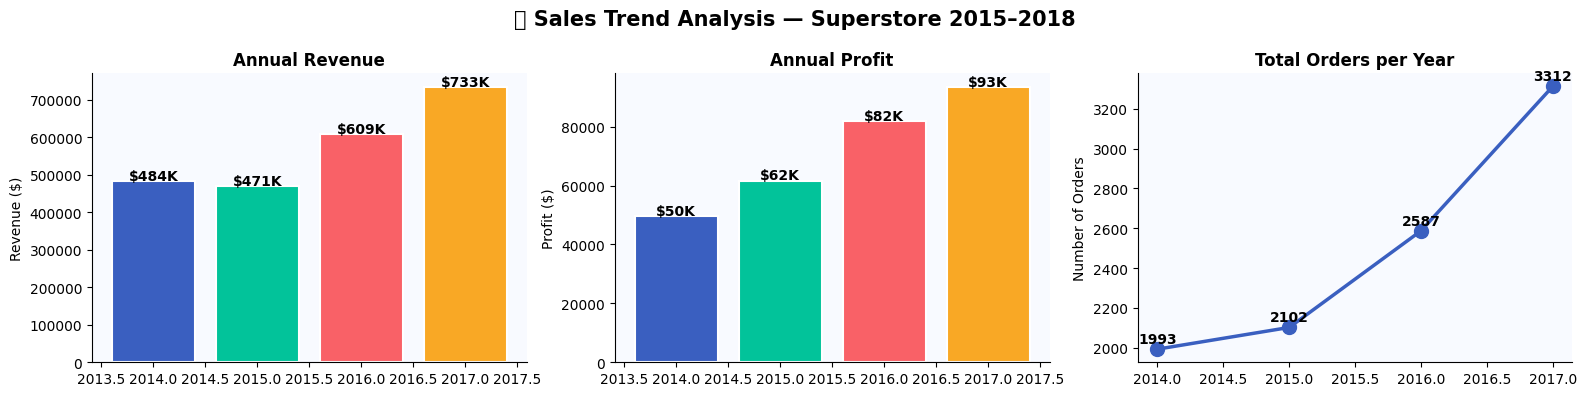


📌 Revenue grew 51.4% from 2015 to 2018
   Best Year: 2017 — $733,215


In [4]:
yearly = df.groupby('Year').agg(
    Revenue=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','count')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('📈 Sales Trend Analysis — Superstore 2015–2018', fontsize=15, fontweight='bold')
colors = ['#3A5FC0', '#02C39A', '#F96167', '#F9A825']

bars = axes[0].bar(yearly['Year'], yearly['Revenue'], color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, yearly['Revenue']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                 f'${val/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Annual Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_facecolor('#F8FAFF')

bars2 = axes[1].bar(yearly['Year'], yearly['Profit'], color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, yearly['Profit']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'${val/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Annual Profit', fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].set_facecolor('#F8FAFF')

axes[2].plot(yearly['Year'], yearly['Orders'], marker='o', color='#3A5FC0', linewidth=2.5, markersize=10)
for x, y in zip(yearly['Year'], yearly['Orders']):
    axes[2].text(x, y+30, str(y), ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Total Orders per Year', fontweight='bold')
axes[2].set_ylabel('Number of Orders')
axes[2].set_facecolor('#F8FAFF')

plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

growth = (yearly['Revenue'].iloc[-1] - yearly['Revenue'].iloc[0]) / yearly['Revenue'].iloc[0] * 100
print(f'\n📌 Revenue grew {growth:.1f}% from 2015 to 2018')
print(f'   Best Year: {yearly.loc[yearly["Revenue"].idxmax(), "Year"]} — ${yearly["Revenue"].max():,.0f}')

---
## 🗺️ Step 4 — Regional & Category Analysis (Part 2 & 3 Findings)

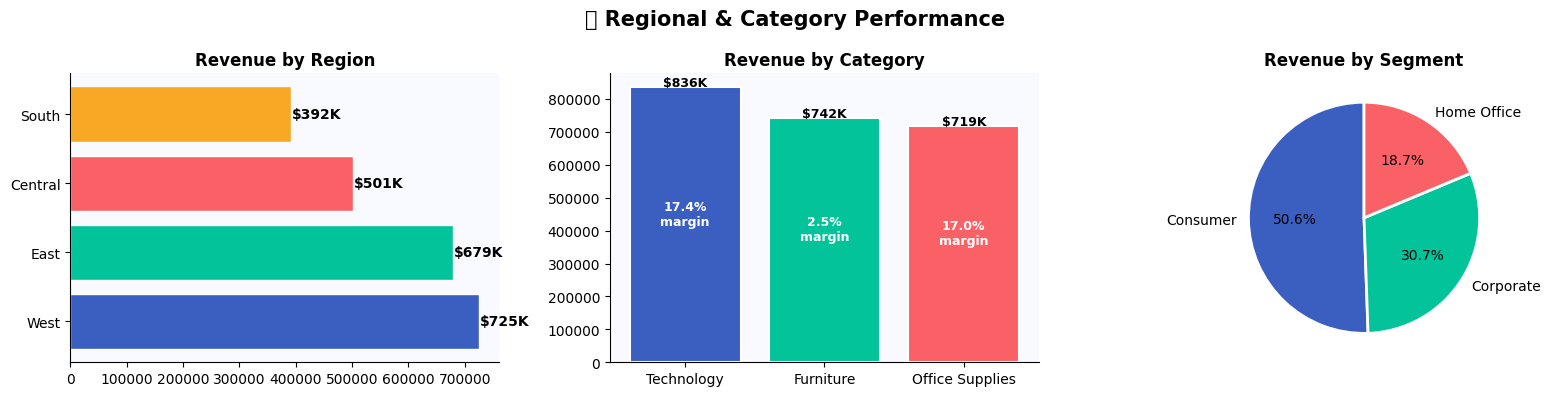

📌 Top Region   : West — $725,458
   Top Category : Technology — $836,154


In [5]:
region_data = df.groupby('Region').agg(Revenue=('Sales','sum'), Profit=('Profit','sum')).reset_index().sort_values('Revenue', ascending=False)
cat_data    = df.groupby('Category').agg(Revenue=('Sales','sum'), Profit=('Profit','sum')).reset_index().sort_values('Revenue', ascending=False)
seg_data    = df.groupby('Segment').agg(Revenue=('Sales','sum')).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('🗺️ Regional & Category Performance', fontsize=15, fontweight='bold')

region_colors = ['#3A5FC0','#02C39A','#F96167','#F9A825']
bars = axes[0].barh(region_data['Region'], region_data['Revenue'], color=region_colors, edgecolor='white')
for bar, val in zip(bars, region_data['Revenue']):
    axes[0].text(bar.get_width()+2000, bar.get_y()+bar.get_height()/2,
                 f'${val/1000:.0f}K', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Revenue by Region', fontweight='bold')
axes[0].set_facecolor('#F8FAFF')

cat_colors = ['#3A5FC0','#02C39A','#F96167']
axes[1].bar(cat_data['Category'], cat_data['Revenue'], color=cat_colors, edgecolor='white', linewidth=1.5)
for i, (rev, prof) in enumerate(zip(cat_data['Revenue'], cat_data['Profit'])):
    axes[1].text(i, rev+2000, f'${rev/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i, rev/2, f'{prof/rev*100:.1f}%\nmargin', ha='center', fontsize=9, color='white', fontweight='bold')
axes[1].set_title('Revenue by Category', fontweight='bold')
axes[1].set_facecolor('#F8FAFF')

axes[2].pie(seg_data['Revenue'], labels=seg_data['Segment'], autopct='%1.1f%%',
            colors=['#3A5FC0','#02C39A','#F96167'],
            wedgeprops={'edgecolor':'white','linewidth':2}, startangle=90)
axes[2].set_title('Revenue by Segment', fontweight='bold')

plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📌 Top Region   : {region_data.iloc[0]["Region"]} — ${region_data.iloc[0]["Revenue"]:,.0f}')
print(f'   Top Category : {cat_data.iloc[0]["Category"]} — ${cat_data.iloc[0]["Revenue"]:,.0f}')

---
## 🔬 Step 5 — Hypothesis Testing Setup

**H₀:** Discounts do NOT significantly reduce profit  
**H₁:** Discounts significantly reduce profit

**Group A (Control):** Orders with NO discount  
**Group B (Treatment):** Orders WITH discount

In [6]:
no_discount  = df[df['Discount'] == 0]['Profit']
has_discount = df[df['Discount'] >  0]['Profit']

print('=' * 55)
print('🔬  GROUP SUMMARY')
print('=' * 55)
print(f'  Group A — No Discount  : {len(no_discount):,} orders')
print(f'    Avg Profit : ${no_discount.mean():,.2f}')
print(f'    Std Dev    : ${no_discount.std():,.2f}')
print()
print(f'  Group B — With Discount: {len(has_discount):,} orders')
print(f'    Avg Profit : ${has_discount.mean():,.2f}')
print(f'    Std Dev    : ${has_discount.std():,.2f}')
print()
print(f'  Difference   : ${no_discount.mean() - has_discount.mean():,.2f} more profit without discount')
print('=' * 55)

🔬  GROUP SUMMARY
  Group A — No Discount  : 4,798 orders
    Avg Profit : $66.90
    Std Dev    : $257.06

  Group B — With Discount: 5,196 orders
    Avg Profit : $-6.66
    Std Dev    : $204.81

  Difference   : $73.56 more profit without discount


---
## 📊 Step 6 — Visualize: Discount Impact on Profit

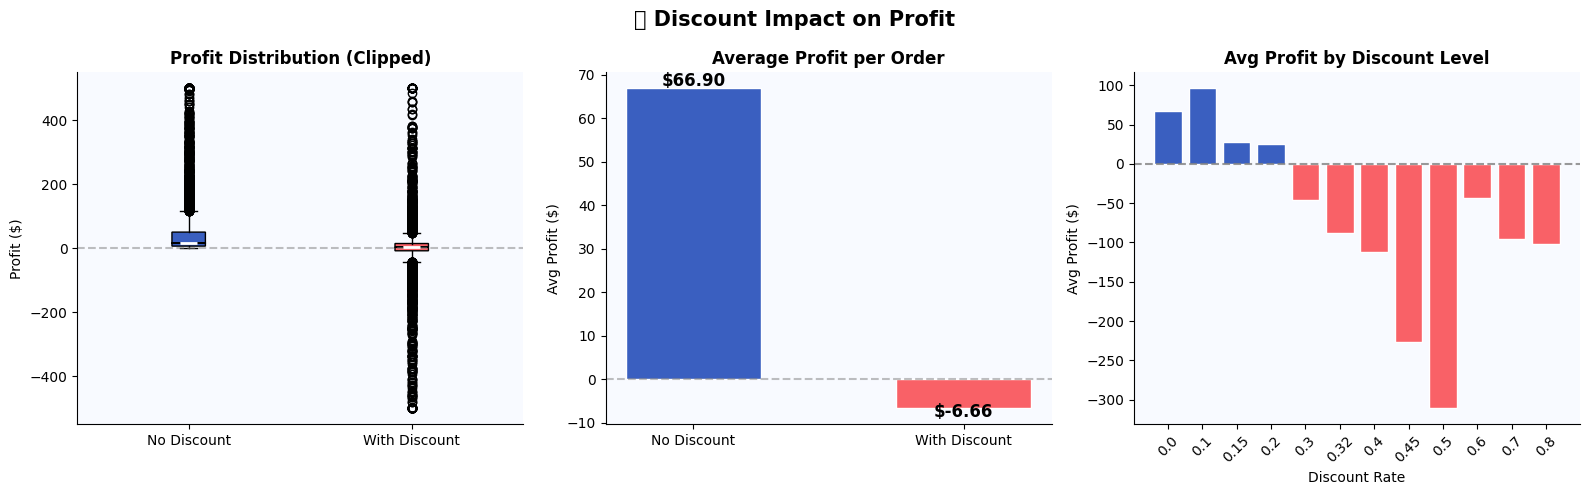

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('💸 Discount Impact on Profit', fontsize=15, fontweight='bold')

# Box Plot
bp = axes[0].boxplot([no_discount.clip(-500, 500), has_discount.clip(-500, 500)],
                     labels=['No Discount', 'With Discount'], patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#3A5FC0')
bp['boxes'][1].set_facecolor('#F96167')
for m in bp['medians']:
    m.set_color('white'); m.set_linewidth(2)
axes[0].set_title('Profit Distribution (Clipped)', fontweight='bold')
axes[0].set_ylabel('Profit ($)')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_facecolor('#F8FAFF')

# Avg Profit Bar
avgs = [no_discount.mean(), has_discount.mean()]
bars = axes[1].bar(['No Discount', 'With Discount'], avgs, color=['#3A5FC0','#F96167'], edgecolor='white', width=0.5)
for bar, val in zip(bars, avgs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.5 if val >= 0 else -2),
                 f'${val:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Average Profit per Order', fontweight='bold')
axes[1].set_ylabel('Avg Profit ($)')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_facecolor('#F8FAFF')

# Discount level vs Avg Profit
disc_profit = df.groupby('Discount')['Profit'].mean().reset_index()
axes[2].bar(disc_profit['Discount'].astype(str), disc_profit['Profit'],
            color=['#3A5FC0' if p > 0 else '#F96167' for p in disc_profit['Profit']], edgecolor='white')
axes[2].set_title('Avg Profit by Discount Level', fontweight='bold')
axes[2].set_ylabel('Avg Profit ($)')
axes[2].set_xlabel('Discount Rate')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.8)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_facecolor('#F8FAFF')

plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔬 Step 7 — T-Test Results

In [8]:
t_stat, p_value = stats.ttest_ind(no_discount, has_discount, equal_var=False)

print('=' * 55)
print('🔬  WELCH T-TEST RESULTS')
print('=' * 55)
print(f'  T-Statistic : {t_stat:.4f}')
print(f'  P-Value     : {p_value:.6f}')
print(f'  Alpha       : 0.05')
print()
if p_value < 0.05:
    print('  ✅ STATISTICALLY SIGNIFICANT (p < 0.05)')
    print('  → Discounts DO significantly reduce profit!')
else:
    print('  ❌ NOT SIGNIFICANT (p >= 0.05)')
print('=' * 55)

🔬  WELCH T-TEST RESULTS
  T-Statistic : 15.7380
  P-Value     : 0.000000
  Alpha       : 0.05

  ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
  → Discounts DO significantly reduce profit!


---
## 📏 Step 8 — 95% Confidence Interval

In [9]:
diff     = no_discount.mean() - has_discount.mean()
se_diff  = np.sqrt(no_discount.var()/len(no_discount) + has_discount.var()/len(has_discount))
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print('=' * 55)
print('📏  95% CONFIDENCE INTERVAL')
print('=' * 55)
print(f'  No Discount Avg Profit   : ${no_discount.mean():,.2f}')
print(f'  With Discount Avg Profit : ${has_discount.mean():,.2f}')
print(f'  Mean Difference          : ${diff:,.2f}')
print(f'  95% CI : [${ci_lower:,.2f}, ${ci_upper:,.2f}]')
print()
print(f'  📌 Orders without discount earn')
print(f'  ${ci_lower:,.2f}–${ci_upper:,.2f} MORE profit on average.')
print('=' * 55)

📏  95% CONFIDENCE INTERVAL
  No Discount Avg Profit   : $66.90
  With Discount Avg Profit : $-6.66
  Mean Difference          : $73.56
  95% CI : [$64.40, $82.72]

  📌 Orders without discount earn
  $64.40–$82.72 MORE profit on average.


---
## 📊 Step 9 — Effect Size & Chi-Squared Test

In [10]:
# Cohen's d
pooled_std = np.sqrt(
    ((len(no_discount)-1)*no_discount.std()**2 + (len(has_discount)-1)*has_discount.std()**2) /
    (len(no_discount) + len(has_discount) - 2)
)
cohens_d     = (no_discount.mean() - has_discount.mean()) / pooled_std
effect_label = 'Small' if abs(cohens_d) < 0.5 else ('Medium' if abs(cohens_d) < 0.8 else 'Large')

print(f'  Cohen\'s d : {cohens_d:.4f} ({effect_label} effect)\n')

# Chi-Squared
df['High Discount'] = df['Discount'].apply(lambda x: 'High (>20%)' if x > 0.2 else 'Low/No')
df['Loss']          = df['Profit'].apply(lambda x: 'Loss' if x < 0 else 'Profit')
ct = pd.crosstab(df['High Discount'], df['Loss'])

print('Contingency Table:')
print(ct)

chi2, p_chi2, dof, _ = stats.chi2_contingency(ct)
print()
print('=' * 55)
print('📋  CHI-SQUARED TEST')
print('=' * 55)
print(f'  Chi2 = {chi2:.4f} | p = {p_chi2:.6f} | dof = {dof}')
if p_chi2 < 0.05:
    print('  ✅ High-discount orders are significantly')
    print('  more likely to result in a LOSS!')
print('=' * 55)

  Cohen's d : 0.3179 (Small effect)

Contingency Table:
Loss           Loss  Profit
High Discount              
High (>20%)    1348      45
Low/No          523    8078

📋  CHI-SQUARED TEST
  Chi2 = 6473.7755 | p = 0.000000 | dof = 1
  ✅ High-discount orders are significantly
  more likely to result in a LOSS!


---
## ✅ Step 10 — Final Business Conclusion & Call to Action

In [11]:
total_discount_loss = df[df['Discount'] > 0.2]['Profit'].sum()
pct_loss_orders     = (df[df['Profit'] < 0].shape[0] / len(df)) * 100

print('=' * 65)
print('  ✅  FINAL BUSINESS CONCLUSION')
print('=' * 65)
print()
print('  VERDICT: REJECT H₀ — Discounts significantly reduce profit')
print()
print('  EVIDENCE:')
print(f'  • T-test p-value     = {p_value:.6f}  << 0.05 ✅')
print(f'  • 95% CI             = [${ci_lower:,.2f}, ${ci_upper:,.2f}] ✅')
print(f'  • Chi-squared p      = {p_chi2:.6f} << 0.05 ✅')
print(f'  • Cohen\'s d          = {cohens_d:.4f} ({effect_label})')
print()
print('  BUSINESS IMPACT:')
print(f'  • Avg profit without discount : ${no_discount.mean():,.2f}')
print(f'  • Avg profit with discount    : ${has_discount.mean():,.2f}')
print(f'  • High discount total losses  : ${total_discount_loss:,.2f}')
print(f'  • % of loss-making orders     : {pct_loss_orders:.1f}%')
print()
print('  RECOMMENDATIONS:')
print('  1. → CAP discounts at 20% max to avoid losses')
print('  2. → Prioritize Technology — highest profit margins')
print('  3. → Focus on West & East regions — top revenue')
print('  4. → Target Corporate segment — best order value')
print('  5. → Review Furniture discounting strategy immediately')
print()
print('=' * 65)
print('  Analyst  : Vikas Navik')
print('  GitHub   : github.com/vikasnishad54vertfgcea')
print('  LinkedIn : linkedin.com/in/vikas-navik-a00029313')
print('=' * 65)

  ✅  FINAL BUSINESS CONCLUSION

  VERDICT: REJECT H₀ — Discounts significantly reduce profit

  EVIDENCE:
  • T-test p-value     = 0.000000  << 0.05 ✅
  • 95% CI             = [$64.40, $82.72] ✅
  • Chi-squared p      = 0.000000 << 0.05 ✅
  • Cohen's d          = 0.3179 (Small)

  BUSINESS IMPACT:
  • Avg profit without discount : $66.90
  • Avg profit with discount    : $-6.66
  • High discount total losses  : $-135,376.06
  • % of loss-making orders     : 18.7%

  RECOMMENDATIONS:
  1. → CAP discounts at 20% max to avoid losses
  2. → Prioritize Technology — highest profit margins
  3. → Focus on West & East regions — top revenue
  4. → Target Corporate segment — best order value
  5. → Review Furniture discounting strategy immediately

  Analyst  : Vikas Navik
  GitHub   : github.com/vikasnishad54vertfgcea
  LinkedIn : linkedin.com/in/vikas-navik-a00029313
